# ___Root Trait Data from Vin___
-----------------------------

In [1]:
!python --version

Python 3.13.9


The system cannot find the path specified.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
SITE_CODE_LOOKUP = {
    "Virginia Gardens_SA": "A", # TT4
    "Dalby_QLD": "B", # TT6
    "Sydney": "C", # TT7
    "Mt Fox N Park_QLD": "D", # TT13
    "Panawonica_WA": "E", # TT15
    "Rainbow Valley_NT": "F" # TT17
}

themeda = pd.read_csv(r"../../data/chapter3/vin_themeda_root_traits.csv")
themeda.loc[:, "Accession"] = themeda.Accession.replace(SITE_CODE_LOOKUP)
themeda = themeda.sort_values(by="Accession") # key=lambda x: x.str.replace("TT", '').astype(int))
summary = themeda.loc[:, ["SRL", "RTD", "Diameter", "Accession"]].groupby("Accession", sort=True).mean()

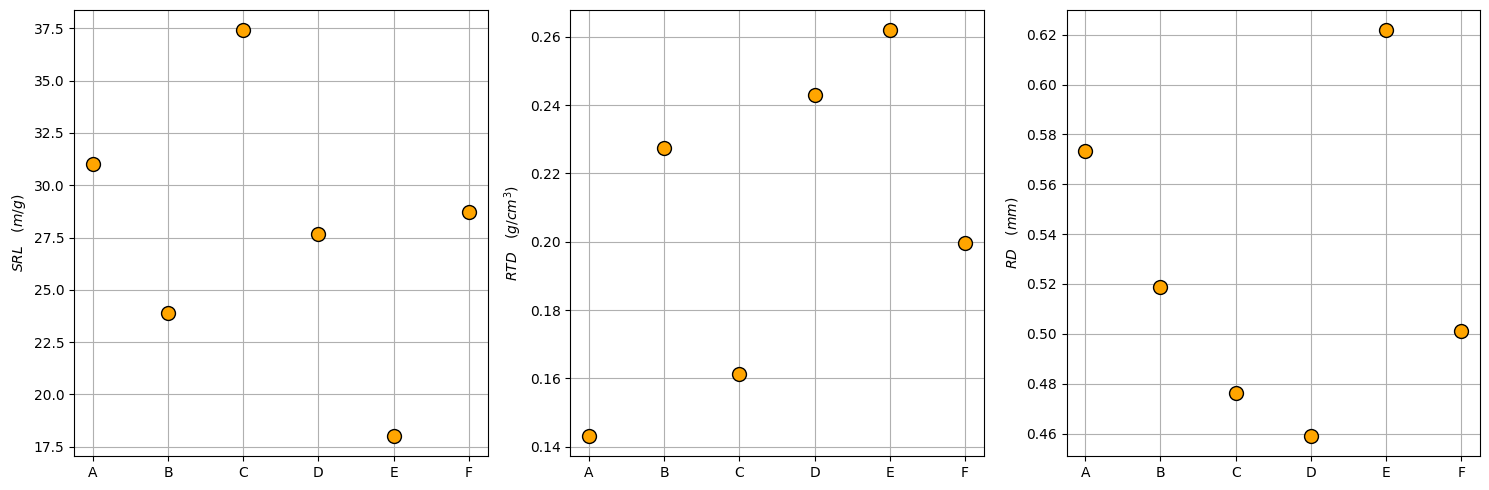

In [11]:
fig, (axis_0, axis_1, axis_2) = plt.subplots(ncols=3)
fig.set_size_inches(15, 5)

axis_0.scatter(summary.index, summary.SRL, edgecolor="black", color="orange", s=100)
axis_0.set_ylabel(r"$SRL\hspace{1}(m/g)$")
axis_0.grid()
axis_0.set_axisbelow(True)

axis_1.scatter(summary.index, summary.RTD, edgecolor="black", color="orange", s=100)
axis_1.set_ylabel(r"$RTD\hspace{1}(g/cm^3)$")
axis_1.grid()
axis_1.set_axisbelow(True)

axis_2.scatter(summary.index, summary.Diameter, edgecolor="black", color="orange", s=100)
axis_2.set_ylabel(r"$RD\hspace{1}(mm)$")
axis_2.grid()
axis_2.set_axisbelow(True)

plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/roottraits.png", format="png", dpi=500)

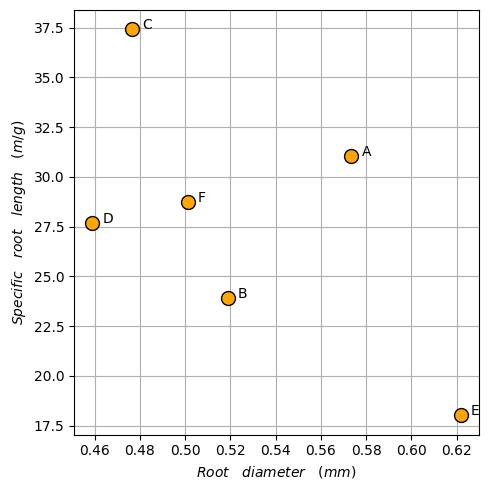

In [5]:
fig, axes = plt.subplots()
fig.set_size_inches(5, 5)
axes.scatter(summary.Diameter, summary.SRL, edgecolor="black", color="orange", s=100)
for idx, row in summary.iterrows():
    axes.text(row.Diameter+0.0045, row.SRL, color="black", s=idx)
axes.set_xlabel(r"$Root\hspace{1}diameter\hspace{1}(mm)$")
axes.set_ylabel(r"$Specific\hspace{1}root\hspace{1}length\hspace{1}(m/g)$")
axes.grid()
axes.set_axisbelow(True)
plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/roottraits.png", format="png", dpi=500)

In [6]:
summary

,SRL,RTD,Diameter
Accession,,,
A,31.022919,0.143106,0.573444
B,23.889177,0.227588,0.518725
C,37.411013,0.161221,0.476333
D,27.673964,0.243022,0.459000
E,18.010786,0.261949,0.621800
F,28.718094,0.199593,0.501140


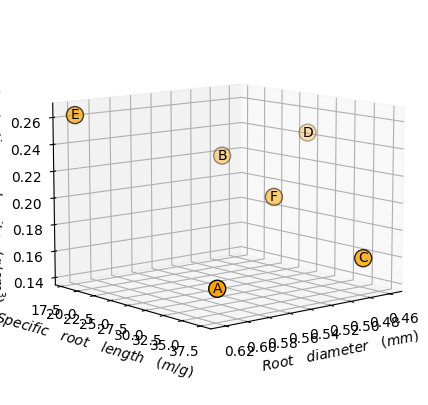

In [21]:
# plot RD, SRL & RTD
fig = plt.figure()
axes = fig.add_subplot(projection="3d")
fig.set_size_inches(5, 5)

axes.scatter(xs=summary.Diameter, ys=summary.SRL, zs=summary.RTD, edgecolor="black", color="orange", s=150)
for idx, row in summary.iterrows():
    axes.text(x=row.Diameter, y=row.SRL, z=row.RTD, ha="center", va="center", color="black", s=idx)
axes.view_init(elev=10, azim=50, roll=0)
axes.set_xlabel(r"$Root\hspace{1}diameter\hspace{1}(mm)$")
axes.set_ylabel(r"$Specific\hspace{1}root\hspace{1}length\hspace{1}(m/g)$")
axes.set_zlabel(r"$Root\hspace{1}tissue\hspace{1}density\hspace{1}(g/cm^3)$")
# plt.tight_layout()
plt.show()